# Benchmarking Mistral & DeepSeek (via Ollama) on Open-Source Datasets — v2

Author: Nimai Chand Das Adhikari  
Reviewed By:  
Team: Microsoft / Azure-Migrate

## What's new in v2
- **Total token capacity (context window)** is fetched per model via Ollama `/api/show`
- Per-call **`total_tokens`** (prompt + completion) and **`context_utilization`** are recorded
- Per-dataset **stratified sampling** via `DATASET_CAPS`
- **Resumable runs** via on-disk JSONL checkpoint (skip already-completed prompts)
- Per-task **generation budgets + stop sequences** for big speedups
- DeepSeek-R1 `<think>...</think>` traces are auto-suppressed
- **CPU-tuned defaults** (`num_thread`, `num_ctx`, `keep_alive`)
- Streaming **tqdm** progress + early-stop guard for runaway inference time
- Persisted **model_capabilities.csv** with context length / params / quant / size

## Pipeline
1. Verify Ollama daemon
2. Capture device specs (CPU / RAM / disk / GPU)
3. (CPU users) configure threading
4. Pull configured Mistral & DeepSeek variants
5. Probe each model's **context window + parameter count**
6. Inference helper with metrics
7. Load datasets (GSM8K, HellaSwag, ARC-Easy, TruthfulQA, MMLU subject)
8. Run inference, recording latency / throughput / tokens / RAM / GPU memory
9. Score MCQ + GSM8K, summarize, plot, persist CSV/JSON

## Prerequisites
- Ollama daemon at `http://localhost:11434` — https://ollama.com
- Python ≥ 3.9
- Disk space for model weights

## 1. Install Python dependencies

In [1]:
%pip install -q -U requests psutil pandas matplotlib datasets tqdm
%pip install -q -U pynvml GPUtil  # optional GPU monitoring

Note: you may need to restart the kernel to use updated packages.


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\dasadhikarin\OneDrive - Microsoft\Desktop\ai\.venv\Lib\site-packages\pip\_internal\cli\base_command.py", line 107, in _run_wrapper
    status = _inner_run()
  File "C:\Users\dasadhikarin\OneDrive - Microsoft\Desktop\ai\.venv\Lib\site-packages\pip\_internal\cli\base_command.py", line 98, in _inner_run
    return self.run(options, args)
           ~~~~~~~~^^^^^^^^^^^^^^^
  File "C:\Users\dasadhikarin\OneDrive - Microsoft\Desktop\ai\.venv\Lib\site-packages\pip\_internal\cli\req_command.py", line 96, in wrapper
    return func(self, options, args)
  File "C:\Users\dasadhikarin\OneDrive - Microsoft\Desktop\ai\.venv\Lib\site-packages\pip\_internal\commands\install.py", line 340, in run
    session = self.get_default_session(options)
  File "C:\Users\dasadhikarin\OneDrive - Microsoft\Desktop\ai\.venv\Lib\site-packages\pip\_internal\cli\index_command.py", line 82, in get_default_session
    self._session = self.enter_context

Note: you may need to restart the kernel to use updated packages.


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\dasadhikarin\OneDrive - Microsoft\Desktop\ai\.venv\Lib\site-packages\pip\_internal\cli\base_command.py", line 107, in _run_wrapper
    status = _inner_run()
  File "C:\Users\dasadhikarin\OneDrive - Microsoft\Desktop\ai\.venv\Lib\site-packages\pip\_internal\cli\base_command.py", line 98, in _inner_run
    return self.run(options, args)
           ~~~~~~~~^^^^^^^^^^^^^^^
  File "C:\Users\dasadhikarin\OneDrive - Microsoft\Desktop\ai\.venv\Lib\site-packages\pip\_internal\cli\req_command.py", line 96, in wrapper
    return func(self, options, args)
  File "C:\Users\dasadhikarin\OneDrive - Microsoft\Desktop\ai\.venv\Lib\site-packages\pip\_internal\commands\install.py", line 340, in run
    session = self.get_default_session(options)
  File "C:\Users\dasadhikarin\OneDrive - Microsoft\Desktop\ai\.venv\Lib\site-packages\pip\_internal\cli\index_command.py", line 82, in get_default_session
    self._session = self.enter_context

## 2. Verify Ollama is running
If this fails: launch the Ollama app (Windows/macOS) or run `ollama serve` (Linux).

In [2]:
import requests
OLLAMA_URL = 'http://localhost:11434'

try:
    r = requests.get(f'{OLLAMA_URL}/api/tags', timeout=5)
    r.raise_for_status()
    print('Ollama is reachable. Installed models:')
    for m in r.json().get('models', []):
        print(' -', m['name'], f"({m.get('size', 0) / 1e9:.2f} GB)")
except Exception as e:
    print('Could not reach Ollama:', e)
    print('Start the Ollama daemon and re-run this cell.')

Ollama is reachable. Installed models:
 - deepseek-r1:7b (4.68 GB)
 - deepseek-r1:1.5b (1.12 GB)
 - mistral:7b-instruct-q4_K_M (4.37 GB)
 - llama3.2:1b-instruct-q4_K_M (0.81 GB)
 - deepseek-r1:latest (5.23 GB)
 - mistral:latest (4.37 GB)


## 3. Capture device / system specifications

In [3]:
import os, json, platform, shutil, time, re
import psutil

def get_gpu_info():
    gpus = []
    try:
        import pynvml
        pynvml.nvmlInit()
        for i in range(pynvml.nvmlDeviceGetCount()):
            h = pynvml.nvmlDeviceGetHandleByIndex(i)
            mem = pynvml.nvmlDeviceGetMemoryInfo(h)
            gpus.append({
                'index': i,
                'name': pynvml.nvmlDeviceGetName(h),
                'memory_total_gb': round(mem.total / 1e9, 2),
                'memory_used_gb': round(mem.used / 1e9, 2),
                'driver': pynvml.nvmlSystemGetDriverVersion(),
                'vendor': 'NVIDIA',
            })
        pynvml.nvmlShutdown()
    except Exception:
        pass
    if not gpus:
        try:
            import GPUtil
            for g in GPUtil.getGPUs():
                gpus.append({
                    'index': g.id, 'name': g.name,
                    'memory_total_gb': round(g.memoryTotal / 1024, 2),
                    'memory_used_gb': round(g.memoryUsed / 1024, 2),
                    'driver': getattr(g, 'driver', 'unknown'),
                    'vendor': 'NVIDIA',
                })
        except Exception:
            pass
    return gpus

DEVICE_INFO = {
    'os': f'{platform.system()} {platform.release()}',
    'os_version': platform.version(),
    'machine': platform.machine(),
    'processor': platform.processor(),
    'cpu_logical_cores': psutil.cpu_count(logical=True),
    'cpu_physical_cores': psutil.cpu_count(logical=False),
    'ram_total_gb': round(psutil.virtual_memory().total / 1e9, 2),
    'ram_available_gb': round(psutil.virtual_memory().available / 1e9, 2),
    'disk_free_gb': round(shutil.disk_usage(os.getcwd()).free / 1e9, 2),
    'python': platform.python_version(),
    'gpus': get_gpu_info(),
}
DEVICE_INFO['gpu_available'] = bool(DEVICE_INFO['gpus'])
print(json.dumps(DEVICE_INFO, indent=2, default=str))

{
  "os": "Windows 11",
  "os_version": "10.0.26200",
  "machine": "AMD64",
  "processor": "Intel64 Family 6 Model 106 Stepping 6, GenuineIntel",
  "cpu_logical_cores": 16,
  "cpu_physical_cores": 8,
  "ram_total_gb": 68.67,
  "ram_available_gb": 47.07,
  "disk_free_gb": 358.7,
  "python": "3.14.0",
  "gpus": [],
  "gpu_available": false
}


## 3b. CPU performance tuning (read me if no GPU)

On CPU-only systems, you'll get usable speed only with small / quantized models and tight token budgets.

**Set Ollama env vars BEFORE launching the daemon** (close & relaunch the Ollama desktop app on Windows after running this in PowerShell):

```powershell
$env:OLLAMA_NUM_PARALLEL = '1'
$env:OLLAMA_KEEP_ALIVE   = '60m'
# Threads = physical cores (NOT logical):
$env:OLLAMA_NUM_THREAD   = ([int](Get-CimInstance Win32_Processor).NumberOfCores)
```

We also pass `num_thread` (= physical cores) and `num_ctx=2048` per call below.

## 4. Configure & pull models
Edit the `MODELS` list. Browse tags at https://ollama.com/library.

In [4]:
MODELS = [
    # ----- CPU-friendly small / quantized models -----
    'mistral:7b-instruct-q4_K_M',         # ~1-3 tok/s on a modern laptop CPU
    'llama3.2:1b-instruct-q4_K_M',        # very fast on CPU
    'phi3:mini',                          # ~3.8B, decent on CPU (use plain tag; -4k-instruct- variants 404)

    # ----- Qwen family (recommended; strong instruction following) -----
    'qwen2.5:1.5b-instruct',              # tiny + fast, good MCQ accuracy
    'qwen2.5:3b-instruct',                # sweet spot on CPU
    'qwen2.5:7b-instruct-q4_K_M',         # strongest of the Qwen 2.5 set on CPU
    # 'qwen3:8b',                         # newer; uncomment if pulled
    # 'qwen2.5:14b-instruct-q4_K_M',      # GPU-only realistically
    # 'qwen2.5:32b-instruct-q4_K_M',      # GPU-only

    # ----- Gemma family -----
    # NOTE: user requested "Gemma 4 26B"; closest Ollama tag is 'gemma3:27b'.
    # The 27B model needs ~17 GB just for weights at q4 -> GPU strongly recommended.
    'gemma3:1b',                          # CPU-friendly
    'gemma3:4b',                          # CPU-borderline (~2-3 tok/s)
    'gemma4:26b',                         # GPU recommended; latest Gemma family model (swap in when available)
    # 'gemma3:12b',                       # GPU recommended
    # 'gemma3:27b',                       # GPU ONLY (≈17 GB q4); ~0.3-0.8 tok/s on CPU
    # If/when Ollama publishes a Gemma 4 tag, swap in e.g. 'gemma4:26b'.

    # ----- DeepSeek-R1 -----
    # WARNING: R1 is a reasoning model; it emits <think>...</think> traces that
    # *must* complete before the real answer. Our previous run added '<think>'
    # to the stop list which truncated generation immediately -> ~0% accuracy.
    # Recommended: large num_predict (>=512) and post-process by stripping the
    # <think> block; do NOT add '<think>' to stops. See learnings doc §2.3.
    # 'deepseek-r1:1.5b',                 # disabled (poor benchmark accuracy under previous config)
    # 'deepseek-r1:7b',                   # AVOID on CPU (~1-2 tok/s)
    # 'deepseek-r1:8b',                   # GPU only
    # 'deepseek-r1:14b',                  # GPU only

    # ----- MoE / very large -----
    # 'mixtral:8x7b',                     # AVOID on CPU
]

def ollama_pull(model: str):
    print(f'\n>>> Pulling {model} ...')
    with requests.post(f'{OLLAMA_URL}/api/pull', json={'name': model}, stream=True, timeout=None) as r:
        r.raise_for_status()
        last_status = None
        for line in r.iter_lines():
            if not line:
                continue
            try:
                data = json.loads(line.decode('utf-8'))
            except Exception:
                continue
            status = data.get('status')
            if status and status != last_status:
                print('  ', status)
                last_status = status
            if data.get('error'):
                raise RuntimeError(data['error'])
    print(f'<<< Done: {model}')

for m in MODELS:
    try:
        ollama_pull(m)
    except Exception as e:
        print(f'Failed to pull {m}: {e}')


>>> Pulling mistral:7b-instruct-q4_K_M ...
   pulling manifest
   pulling faf975975644
   pulling 43070e2d4e53
   pulling 22e1b2e8dc2f
   pulling ed11eda7790d
   pulling 126aeb334a49
   verifying sha256 digest
   writing manifest
   success
<<< Done: mistral:7b-instruct-q4_K_M

>>> Pulling llama3.2:1b-instruct-q4_K_M ...
   pulling manifest
   pulling 84fffd9ce0ec
   pulling 966de95ca8a6
   pulling fcc5a6bec9da
   pulling a70ff7e570d9
   pulling bbb3b1633f7e
   verifying sha256 digest
   writing manifest
   success
<<< Done: llama3.2:1b-instruct-q4_K_M

>>> Pulling phi3:mini ...
   pulling manifest
   pulling 633fc5be925f
   pulling fa8235e5b48f
   pulling 542b217f179c
   pulling 8dde1baf1db0
   pulling 23291dc44752
   verifying sha256 digest
   writing manifest
   success
<<< Done: phi3:mini

>>> Pulling qwen2.5:1.5b-instruct ...
   pulling manifest
   pulling 183715c43589
   pulling 66b9ea09bd5b
   pulling eb4402837c78
   pulling 832dd9e00a68
   pulling 377ac4d7aeef
   verifying sha

## 4b. Probe each model's total token capacity (context window)
We hit `/api/show` and read:
- **`context_length`** — max total tokens (prompt + completion)
- parameter count, quantization, family, file size on disk

In [5]:
import pandas as pd

def get_model_info(model: str) -> dict:
    info = {
        'model': model, 'context_length': None, 'embedding_length': None,
        'parameter_count': None, 'parameter_size': None,
        'quantization': None, 'family': None, 'size_gb': None,
    }
    try:
        r = requests.post(f'{OLLAMA_URL}/api/show', json={'name': model}, timeout=30)
        r.raise_for_status()
        data = r.json()
    except Exception as e:
        info['error'] = str(e)
        return info

    details = data.get('details') or {}
    info['family'] = details.get('family')
    info['quantization'] = details.get('quantization_level')
    info['parameter_size'] = details.get('parameter_size')

    model_info = data.get('model_info') or {}
    for k, v in model_info.items():
        if k.endswith('.context_length') and info['context_length'] is None:
            info['context_length'] = v
        elif k.endswith('.embedding_length') and info['embedding_length'] is None:
            info['embedding_length'] = v
        elif k == 'general.parameter_count':
            info['parameter_count'] = v

    try:
        for entry in requests.get(f'{OLLAMA_URL}/api/tags', timeout=10).json().get('models', []):
            if entry['name'] == model:
                info['size_gb'] = round(entry.get('size', 0) / 1e9, 2)
                break
    except Exception:
        pass
    return info

MODEL_INFO = {m: get_model_info(m) for m in MODELS}
model_caps_df = pd.DataFrame(MODEL_INFO.values())
model_caps_df

,model,context_length,embedding_length,parameter_count,parameter_size,quantization,family,size_gb
0,mistral:7b-instruct-q4_K_M,32768,4096,7241732096,7B,Q4_K_M,llama,4.37
1,llama3.2:1b-instruct-q4_K_M,131072,2048,1235814432,1.2B,Q4_K_M,llama,0.81
2,phi3:mini,131072,3072,3821079648,3.8B,Q4_0,phi3,2.18
3,qwen2.5:1.5b-instruct,32768,1536,1543714304,1.5B,Q4_K_M,qwen2,0.99
4,qwen2.5:3b-instruct,32768,2048,3085938688,3.1B,Q4_K_M,qwen2,1.93
5,qwen2.5:7b-instruct-q4_K_M,32768,3584,7615616512,7.6B,Q4_K_M,qwen2,4.68
6,gemma3:1b,32768,1152,999885952,999.89M,Q4_K_M,gemma3,0.82
7,gemma3:4b,131072,2560,4299915632,4.3B,Q4_K_M,gemma3,3.34
8,gemma4:26b,262144,2816,25805936462,25.8B,Q4_K_M,gemma4,17.99


## 5. Inference helper with metrics
Calls `/api/generate` (non-streaming). Records:
- wall latency, Ollama-reported timings
- prompt / completion / **total** tokens
- **context utilization** = total_tokens / context_length
- RAM and GPU memory deltas

CPU-friendly defaults: `num_thread = physical cores`, `num_ctx = 2048`, `keep_alive = 60m`, `request_timeout = 1800`.

In [6]:
from typing import Optional

def gpu_mem_used_gb() -> Optional[float]:
    try:
        import pynvml
        pynvml.nvmlInit()
        total = 0
        for i in range(pynvml.nvmlDeviceGetCount()):
            h = pynvml.nvmlDeviceGetHandleByIndex(i)
            total += pynvml.nvmlDeviceGetMemoryInfo(h).used
        pynvml.nvmlShutdown()
        return round(total / 1e9, 3)
    except Exception:
        return None

def ram_used_gb() -> float:
    vm = psutil.virtual_memory()
    return round((vm.total - vm.available) / 1e9, 3)

DEFAULT_NUM_THREAD = psutil.cpu_count(logical=False) or 4

def ollama_generate(model: str, prompt: str, max_tokens: int = 256, temperature: float = 0.0,
                    stop=None, keep_alive: str = '60m', request_timeout: int = 1800,
                    num_ctx: int = 2048, num_thread: Optional[int] = None):
    options = {
        'num_predict': max_tokens,
        'temperature': temperature,
        'num_ctx': num_ctx,
        'num_thread': num_thread if num_thread is not None else DEFAULT_NUM_THREAD,
    }
    if stop:
        options['stop'] = list(stop)
    payload = {
        'model': model, 'prompt': prompt, 'stream': False,
        'keep_alive': keep_alive,
        'options': options,
    }

    ram_before = ram_used_gb()
    gpu_before = gpu_mem_used_gb()
    t0 = time.perf_counter()
    r = requests.post(f'{OLLAMA_URL}/api/generate', json=payload, timeout=request_timeout)
    wall = time.perf_counter() - t0
    r.raise_for_status()
    data = r.json()
    ram_after = ram_used_gb()
    gpu_after = gpu_mem_used_gb()

    eval_count = data.get('eval_count', 0) or 0
    eval_dur_ns = data.get('eval_duration', 0) or 0
    prompt_count = data.get('prompt_eval_count', 0) or 0
    prompt_dur_ns = data.get('prompt_eval_duration', 0) or 0
    total_ns = data.get('total_duration', 0) or 0
    load_ns = data.get('load_duration', 0) or 0
    tps = (eval_count / (eval_dur_ns / 1e9)) if eval_dur_ns else None

    return {
        'response': (data.get('response') or '').strip(),
        'wall_seconds': round(wall, 4),
        'total_duration_s': round(total_ns / 1e9, 4),
        'load_duration_s': round(load_ns / 1e9, 4),
        'prompt_tokens': prompt_count,
        'prompt_eval_s': round(prompt_dur_ns / 1e9, 4),
        'completion_tokens': eval_count,
        'completion_eval_s': round(eval_dur_ns / 1e9, 4),
        'total_tokens': prompt_count + eval_count,
        'tokens_per_sec': round(tps, 2) if tps else None,
        'ram_before_gb': ram_before, 'ram_after_gb': ram_after,
        'ram_delta_gb': round(ram_after - ram_before, 3),
        'gpu_before_gb': gpu_before, 'gpu_after_gb': gpu_after,
        'gpu_delta_gb': round(gpu_after - gpu_before, 3) if (gpu_before is not None and gpu_after is not None) else None,
    }

if MODELS:
    smoke = ollama_generate(MODELS[0], 'Reply with a single word: Hello.', max_tokens=10)
    print(json.dumps(smoke, indent=2))

{
  "response": "Hello.",
  "wall_seconds": 12.2048,
  "total_duration_s": 10.1709,
  "load_duration_s": 9.1976,
  "prompt_tokens": 19,
  "prompt_eval_s": 0.7977,
  "completion_tokens": 3,
  "completion_eval_s": 0.1707,
  "total_tokens": 22,
  "tokens_per_sec": 17.57,
  "ram_before_gb": 21.364,
  "ram_after_gb": 26.086,
  "ram_delta_gb": 4.722,
  "gpu_before_gb": null,
  "gpu_after_gb": null,
  "gpu_delta_gb": null
}


## 6. Load open-source datasets (stratified sampling)
Each dataset is downsampled per `DATASET_CAPS` using **stratified random sampling by gold label** (so every class is represented). Set a value to `None` to use the full split.

Defaults are tuned for **CPU**: ~500 items total.

In [7]:
import random
from datasets import load_dataset
from collections import Counter, defaultdict

DATASET_CAPS = {
    'gsm8k':              50,    # numeric_exact is the most expensive task on CPU
    'hellaswag':          150,
    'arc_easy':           150,
    'truthfulqa':         50,
    'mmlu_world_history': 100,
}
SAMPLE_SEED = 42

def _take(items, name):
    cap = DATASET_CAPS.get(name)
    if cap is None or cap >= len(items):
        return items
    rng = random.Random(SAMPLE_SEED)
    by_label = defaultdict(list)
    for it in items:
        by_label[str(it.get('gold', ''))].append(it)
    if len(by_label) > 1 and len(by_label) <= cap:
        per = max(1, cap // len(by_label))
        out = []
        for lab, group in by_label.items():
            rng.shuffle(group)
            out.extend(group[:per])
        rng.shuffle(out)
        return out[:cap]
    sampled = items[:]
    rng.shuffle(sampled)
    return sampled[:cap]

def safe_load(loader_fn, name):
    try:
        return loader_fn()
    except Exception as e:
        print(f'[skip] {name}: {e}')
        return []

def load_gsm8k():
    ds = load_dataset('gsm8k', 'main', split='test')
    items = []
    for ex in ds:
        gold = ex['answer'].split('####')[-1].strip().replace(',', '')
        items.append({
            'dataset': 'gsm8k',
            'prompt': f"Solve the problem and end your answer with '#### <number>'.\n\nQuestion: {ex['question']}\nAnswer:",
            'gold': gold,
            'task_type': 'numeric_exact',
        })
    return _take(items, 'gsm8k')

def load_hellaswag():
    ds = load_dataset('hellaswag', split='validation')
    items = []
    for ex in ds:
        choices = '\n'.join(f'{chr(65 + i)}. {c}' for i, c in enumerate(ex['endings']))
        items.append({
            'dataset': 'hellaswag',
            'prompt': (f"Choose the most likely continuation. Respond with only the letter, no reasoning.\n\n"
                       f"Context: {ex['ctx']}\n{choices}\nAnswer:"),
            'gold': chr(65 + int(ex['label'])),
            'task_type': 'mcq',
        })
    return _take(items, 'hellaswag')

def load_arc():
    ds = load_dataset('allenai/ai2_arc', 'ARC-Easy', split='test')
    items = []
    for ex in ds:
        labels = ex['choices']['label']
        texts = ex['choices']['text']
        choices = '\n'.join(f'{l}. {t}' for l, t in zip(labels, texts))
        items.append({
            'dataset': 'arc_easy',
            'prompt': (f"Answer with only the letter, no reasoning.\n\n"
                       f"Question: {ex['question']}\n{choices}\nAnswer:"),
            'gold': ex['answerKey'],
            'task_type': 'mcq',
        })
    return _take(items, 'arc_easy')

def load_truthfulqa():
    ds = load_dataset('truthful_qa', 'generation', split='validation')
    items = []
    for ex in ds:
        items.append({
            'dataset': 'truthfulqa',
            'prompt': f"Answer truthfully in one sentence.\n\nQuestion: {ex['question']}\nAnswer:",
            'gold': ex.get('best_answer', ''),
            'task_type': 'open',
        })
    return _take(items, 'truthfulqa')

def load_mmlu():
    ds = load_dataset('cais/mmlu', 'high_school_world_history', split='test')
    items = []
    for ex in ds:
        choices = '\n'.join(f'{chr(65 + i)}. {c}' for i, c in enumerate(ex['choices']))
        items.append({
            'dataset': 'mmlu_world_history',
            'prompt': (f"Answer with only the letter (A, B, C, or D), no reasoning.\n\n"
                       f"Question: {ex['question']}\n{choices}\nAnswer:"),
            'gold': chr(65 + int(ex['answer'])),
            'task_type': 'mcq',
        })
    return _take(items, 'mmlu_world_history')

EVAL_ITEMS = []
EVAL_ITEMS += safe_load(load_gsm8k,      'gsm8k')
EVAL_ITEMS += safe_load(load_hellaswag,  'hellaswag')
EVAL_ITEMS += safe_load(load_arc,        'arc_easy')
EVAL_ITEMS += safe_load(load_truthfulqa, 'truthfulqa')
EVAL_ITEMS += safe_load(load_mmlu,       'mmlu_world_history')

# Stable IDs so we can resume
for i, it in enumerate(EVAL_ITEMS):
    it['id'] = f"{it['dataset']}::{i}"

print('Total eval items:', len(EVAL_ITEMS))
print(Counter(it['dataset'] for it in EVAL_ITEMS))

C:\Users\dasadhikarin\OneDrive - Microsoft\Desktop\ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total eval items: 477
Counter({'hellaswag': 148, 'arc_easy': 129, 'mmlu_world_history': 100, 'gsm8k': 50, 'truthfulqa': 50})


## 7. Scoring helpers

In [8]:
MCQ_RE = re.compile(r'\b([A-E])\b')
NUM_RE = re.compile(r'-?\d+(?:\.\d+)?')

def score(task_type: str, gold: str, prediction: str):
    pred = (prediction or '').strip()
    if task_type == 'mcq':
        m = MCQ_RE.findall(pred.upper())
        guess = m[0] if m else ''
        return int(guess == gold.upper()), guess
    if task_type == 'numeric_exact':
        if '####' in pred:
            nums = NUM_RE.findall(pred.split('####')[-1])
        else:
            nums = NUM_RE.findall(pred)
        guess = nums[-1].replace(',', '') if nums else ''
        try:
            return int(float(guess) == float(gold)), guess
        except ValueError:
            return 0, guess
    return None, pred

## 8. Run the benchmark (resumable)

Each result is appended to `RUN_DIR/results.jsonl` so you can interrupt and resume. Existing `(model, id)` rows are skipped. Set `EARLY_STOP_SECONDS` to bail on a model whose average wall latency exceeds the threshold.

In [9]:
from datetime import datetime
from tqdm.auto import tqdm

RUN_DIR = os.environ.get('BENCH_RUN_DIR') or f"benchmark_run_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(RUN_DIR, exist_ok=True)
RESULTS_PATH = os.path.join(RUN_DIR, 'results.jsonl')
print('Run directory:', os.path.abspath(RUN_DIR))

EARLY_STOP_SECONDS = 600.0  # CPU is slow; don't bail prematurely (>=10 calls)

# ---- Per-task generation budgets (BIG speedup, especially on CPU) ----
GEN_CONFIG = {
    'mcq':           {'num_predict': 2,   'stop': ['\n', '.', 'Question:', 'Context:']},
    'numeric_exact': {'num_predict': 128, 'stop': ['Question:', '\n\n']},
    'open':          {'num_predict': 32,  'stop': ['\n', 'Question:']},
}

def extra_stops_for(model: str):
    """DeepSeek-R1 emits <think>...</think> traces that bloat token counts."""
    if 'deepseek-r1' in model.lower():
        return ['<think>', '</think>']
    return []

# Load any prior results to enable resume
completed = set()
if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                row = json.loads(line)
                completed.add((row['model'], row['id']))
            except Exception:
                pass
print(f'Resuming with {len(completed)} previously completed rows.')

def append_jsonl(path, row):
    with open(path, 'a', encoding='utf-8') as f:
        f.write(json.dumps(row, default=str) + '\n')

for model in MODELS:
    print(f'\n=== Benchmarking {model} ===')
    try:
        ollama_generate(model, 'Hello.', max_tokens=4)  # warm-up (loads weights)
    except Exception as e:
        print(f'Warm-up failed for {model}: {e}; skipping.')
        continue

    ctx_len = MODEL_INFO.get(model, {}).get('context_length')
    latencies = []
    pending = [it for it in EVAL_ITEMS if (model, it['id']) not in completed]
    pbar = tqdm(pending, desc=model)
    extra_stop = extra_stops_for(model)
    for item in pbar:
        cfg = GEN_CONFIG[item['task_type']]
        try:
            out = ollama_generate(
                model, item['prompt'],
                max_tokens=cfg['num_predict'],
                stop=list(cfg.get('stop', [])) + extra_stop,
                keep_alive='60m',
            )
            correct, guess = score(item['task_type'], item['gold'], out['response'])
            tt = out.get('total_tokens') or 0
            row = {
                'model': model, 'id': item['id'], 'dataset': item['dataset'],
                'task_type': item['task_type'], 'gold': item['gold'],
                'prediction': out['response'][:300], 'parsed_guess': guess, 'correct': correct,
                'context_length': ctx_len,
                'context_utilization': round(tt / ctx_len, 4) if ctx_len else None,
                **{k: v for k, v in out.items() if k != 'response'},
            }
        except Exception as e:
            row = {'model': model, 'id': item['id'], 'dataset': item['dataset'],
                   'task_type': item['task_type'], 'gold': item['gold'],
                   'prediction': f'ERROR: {e}', 'correct': 0}
        append_jsonl(RESULTS_PATH, row)
        completed.add((model, item['id']))
        if 'wall_seconds' in row:
            latencies.append(row['wall_seconds'])
            pbar.set_postfix(avg_s=round(sum(latencies)/len(latencies), 2),
                             tps=row.get('tokens_per_sec'))
        if len(latencies) >= 10 and (sum(latencies)/len(latencies)) > EARLY_STOP_SECONDS:
            print(f'\nEarly stop: {model} avg wall {sum(latencies)/len(latencies):.1f}s > {EARLY_STOP_SECONDS}s')
            break

# Load all rows back into a DataFrame
with open(RESULTS_PATH, 'r', encoding='utf-8') as f:
    df = pd.DataFrame(json.loads(line) for line in f if line.strip())
print('Total rows:', len(df))
df.head()

Run directory: C:\Users\dasadhikarin\OneDrive - Microsoft\Desktop\ai\benchmark_run_20260512_164937
Resuming with 0 previously completed rows.

=== Benchmarking mistral:7b-instruct-q4_K_M ===


mistral:7b-instruct-q4_K_M: 100%|██████████| 477/477 [1:18:01<00:00,  9.81s/it, avg_s=9.81, tps=None]



=== Benchmarking llama3.2:1b-instruct-q4_K_M ===


llama3.2:1b-instruct-q4_K_M: 100%|██████████| 477/477 [26:15<00:00,  3.30s/it, avg_s=3.3, tps=111]  



=== Benchmarking phi3:mini ===


...

gemma3:4b: 100%|██████████| 477/477 [46:33<00:00,  5.86s/it, avg_s=5.85, tps=36.1] 



=== Benchmarking gemma4:26b ===


gemma4:26b: 100%|██████████| 477/477 [48:08<00:00,  6.05s/it, avg_s=6.05, tps=28.8] 

Total rows: 4293


,model,id,dataset,task_type,gold,prediction,parsed_guess,correct,context_length,context_utilization,...,completion_tokens,completion_eval_s,total_tokens,tokens_per_sec,ram_before_gb,ram_after_gb,ram_delta_gb,gpu_before_gb,gpu_after_gb,gpu_delta_gb
0,mistral:7b-instruct-q4_K_M,gsm8k::0,gsm8k,numeric_exact,52,"To find the average of the three measurements,...",3,0.0,32768,0.0039,...,26,2.1765,128,11.95,26.244,26.236,-0.008,None,None,None
1,mistral:7b-instruct-q4_K_M,gsm8k::1,gsm8k,numeric_exact,5,Jordan changes 7 diapers per day.,7,0.0,32768,0.0028,...,13,1.1085,91,11.73,26.237,26.257,0.020,None,None,None
2,mistral:7b-instruct-q4_K_M,gsm8k::2,gsm8k,numeric_exact,83,The maximum number of boxes that can be loaded...,333,0.0,32768,0.0044,...,31,2.6594,144,11.66,26.258,26.252,-0.006,None,None,None
3,mistral:7b-instruct-q4_K_M,gsm8k::3,gsm8k,numeric_exact,10,"After using 3 blue shoeboxes, Tim has 4 blue s...",6,0.0,32768,0.0056,...,92,8.3441,185,11.03,26.253,25.836,-0.417,None,None,None
4,mistral:7b-instruct-q4_K_M,gsm8k::4,gsm8k,numeric_exact,70,"If there are 20 helmets, then there must be ha...",10,0.0,32768,0.0042,...,50,6.7641,137,7.39,25.838,25.885,0.047,None,None,None


## 9. Summary tables

In [10]:
agg = (df.groupby(['model', 'dataset'])
         .agg(n=('prediction', 'count'),
              accuracy=('correct', lambda s: round(s.dropna().mean(), 3) if s.dropna().size else None),
              avg_latency_s=('wall_seconds', 'mean'),
              avg_tokens_per_sec=('tokens_per_sec', 'mean'),
              avg_prompt_tokens=('prompt_tokens', 'mean'),
              avg_completion_tokens=('completion_tokens', 'mean'),
              avg_total_tokens=('total_tokens', 'mean'),
              max_total_tokens=('total_tokens', 'max'),
              avg_ctx_utilization=('context_utilization', 'mean'),
              avg_ram_delta_gb=('ram_delta_gb', 'mean'),
              avg_gpu_delta_gb=('gpu_delta_gb', 'mean'))
         .round(3))
agg

n  accuracy  avg_latency_s  \
model                       dataset                                            
gemma3:1b                   arc_easy            129     0.341          2.625   
                            gsm8k                50     0.120          4.367   
                            hellaswag           148     0.392          3.201   
                            mmlu_world_history  100     0.430          3.790   
                            truthfulqa           50       NaN          2.776   
gemma3:4b                   arc_easy            129     0.419          3.354   
                            gsm8k                50     0.140          8.897   
                            hellaswag           148     0.554          5.782   
                            mmlu_world_history  100     0.710          8.586   
                            truthfulqa           50       NaN          3.962   
gemma4:26b                  arc_easy            129     0.000          3.478   
                            gsm8k                50     0.000          8.582   
                            hellaswag           148     0.000          6.304   
                            mmlu_world_history  100     0.000          9.271   
                            truthfulqa           50       NaN          2.926   
llama3.2:1b-instruct-q4_K_M arc_easy            129     0.264          2.531   
                            gsm8k                50     0.000          3.247   
                            hellaswag           148     0.270          3.461   
                            mmlu_world_history  100     0.320          4.268   
                            truthfulqa           50       NaN          2.890   
mistral:7b-instruct-q4_K_M  arc_easy            129     0.000          4.345   
                            gsm8k                50     0.160         12.108   
                            hellaswag           148     0.000         10.418   
                            mmlu_world_history  100     0.100         17.384   
                            truthfulqa           50       NaN          4.639   
phi3:mini                   arc_easy            129     0.481          3.221   
                            gsm8k                50     0.120          8.461   
                            hellaswag           148     0.649          6.022   
                            mmlu_world_history  100     0.700          9.971   
                            truthfulqa           50       NaN          3.764   
qwen2.5:1.5b-instruct       arc_easy            129     0.457          2.579   
                            gsm8k                50     0.020          3.293   
                            hellaswag           148     0.554          3.599   
                            mmlu_world_history  100     0.690          4.851   
                            truthfulqa           50       NaN          2.737   
qwen2.5:3b-instruct         arc_easy            129     0.442          2.998   
                            gsm8k                50     0.020          4.294   
                            hellaswag           148     0.682          5.072   
                            mmlu_world_history  100     0.800          7.551   
                            truthfulqa           50       NaN          3.389   
qwen2.5:7b-instruct-q4_K_M  arc_easy            129     0.488          4.064   
                            gsm8k                50     0.020          6.753   
                            hellaswag           148     0.757          9.052   
                            mmlu_world_history  100     0.830         14.430   
                            truthfulqa           50       NaN          4.513   

                                                avg_tokens_per_sec  \
model                       dataset                                  
gemma3:1b                   arc_easy                       102.534   
                            gsm8k                           51.502   
         

In [11]:
model_summary = (df.groupby('model')
                   .agg(n=('prediction', 'count'),
                        avg_accuracy=('correct', lambda s: round(s.dropna().mean(), 3) if s.dropna().size else None),
                        avg_latency_s=('wall_seconds', 'mean'),
                        median_latency_s=('wall_seconds', 'median'),
                        p95_latency_s=('wall_seconds', lambda s: s.quantile(0.95)),
                        avg_tokens_per_sec=('tokens_per_sec', 'mean'),
                        avg_total_tokens=('total_tokens', 'mean'),
                        max_total_tokens=('total_tokens', 'max'),
                        avg_ram_delta_gb=('ram_delta_gb', 'mean'),
                        avg_gpu_delta_gb=('gpu_delta_gb', 'mean'))
                   .round(3))
model_summary['context_length'] = model_summary.index.map(lambda m: MODEL_INFO.get(m, {}).get('context_length'))
model_summary

,n,avg_accuracy,avg_latency_s,median_latency_s,p95_latency_s,avg_tokens_per_sec,avg_total_tokens,max_total_tokens,avg_ram_delta_gb,avg_gpu_delta_gb,context_length
model,,,,,,,,,,,
gemma3:1b,477,0.354,3.246,3.063,5.018,89.695,190.547,681,-0.000,NaN,32768
gemma3:4b,477,0.501,5.849,5.178,11.082,31.635,192.776,681,-0.011,NaN,131072
gemma4:26b,477,0.000,6.046,5.937,11.935,28.247,195.392,688,-0.013,NaN,262144
llama3.2:1b-instruct-q4_K_M,477,0.248,3.296,3.060,4.819,94.816,198.566,719,-0.001,NaN,131072
mistral:7b-instruct-q4_K_M,477,0.042,9.807,7.954,21.516,12.618,207.025,775,-0.002,NaN,32768
phi3:mini,477,0.548,6.111,5.593,12.171,32.334,214.696,785,-0.010,NaN,131072
qwen2.5:1.5b-instruct,477,0.494,3.463,3.103,5.463,80.968,202.943,725,-0.003,NaN,32768
qwen2.5:3b-instruct,477,0.560,4.773,3.918,8.835,45.540,203.482,725,-0.007,NaN,32768
qwen2.5:7b-instruct-q4_K_M,477,0.607,8.114,6.264,16.777,21.238,203.164,725,-0.007,NaN,32768


## 10. Plots

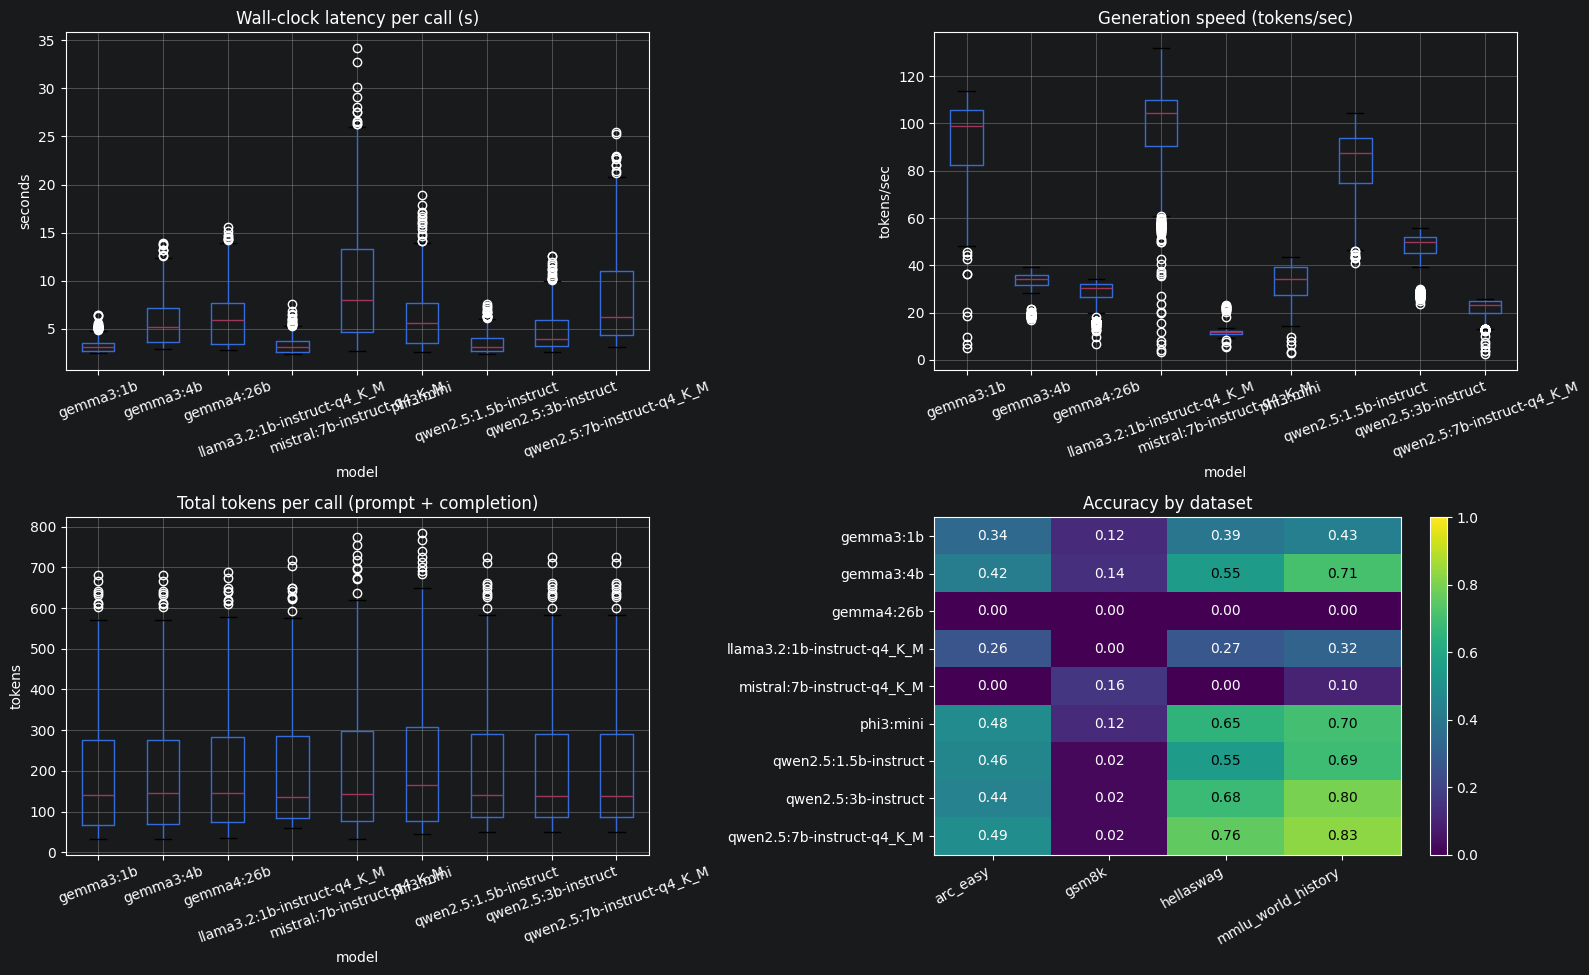

In [12]:
import matplotlib.pyplot as plt

if not df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    df.boxplot(column='wall_seconds', by='model', ax=axes[0, 0])
    axes[0, 0].set_title('Wall-clock latency per call (s)')
    axes[0, 0].set_ylabel('seconds'); axes[0, 0].tick_params(axis='x', rotation=20)

    df.boxplot(column='tokens_per_sec', by='model', ax=axes[0, 1])
    axes[0, 1].set_title('Generation speed (tokens/sec)')
    axes[0, 1].set_ylabel('tokens/sec'); axes[0, 1].tick_params(axis='x', rotation=20)

    df.boxplot(column='total_tokens', by='model', ax=axes[1, 0])
    axes[1, 0].set_title('Total tokens per call (prompt + completion)')
    axes[1, 0].set_ylabel('tokens'); axes[1, 0].tick_params(axis='x', rotation=20)

    scoreable = df[df['correct'].notna()]
    if not scoreable.empty:
        pivot = scoreable.pivot_table(index='model', columns='dataset', values='correct', aggfunc='mean')
        im = axes[1, 1].imshow(pivot.values, vmin=0, vmax=1, cmap='viridis', aspect='auto')
        axes[1, 1].set_xticks(range(len(pivot.columns)))
        axes[1, 1].set_xticklabels(pivot.columns, rotation=30, ha='right')
        axes[1, 1].set_yticks(range(len(pivot.index)))
        axes[1, 1].set_yticklabels(pivot.index)
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                v = pivot.values[i, j]
                axes[1, 1].text(j, i, f'{v:.2f}' if pd.notna(v) else '-', ha='center', va='center',
                                color='white' if pd.notna(v) and v < 0.5 else 'black')
        axes[1, 1].set_title('Accuracy by dataset')
        fig.colorbar(im, ax=axes[1, 1])

    plt.suptitle('')
    plt.tight_layout()
    plt.show()

## 11. Persist results

In [13]:
df.to_csv(os.path.join(RUN_DIR, 'raw_results.csv'), index=False)
agg.to_csv(os.path.join(RUN_DIR, 'per_model_dataset.csv'))
model_summary.to_csv(os.path.join(RUN_DIR, 'per_model_summary.csv'))
model_caps_df.to_csv(os.path.join(RUN_DIR, 'model_capabilities.csv'), index=False)

with open(os.path.join(RUN_DIR, 'device_info.json'), 'w') as f:
    json.dump(DEVICE_INFO, f, indent=2, default=str)

report = {
    'timestamp': datetime.now().isoformat(),
    'device': DEVICE_INFO,
    'models': MODELS,
    'datasets': sorted({it['dataset'] for it in EVAL_ITEMS}),
    'dataset_caps': DATASET_CAPS,
    'gen_config': GEN_CONFIG,
    'total_eval_items': len(EVAL_ITEMS),
    'model_info': MODEL_INFO,
    'per_model_summary': json.loads(model_summary.reset_index().to_json(orient='records')),
    'per_model_dataset': json.loads(agg.reset_index().to_json(orient='records')),
}
with open(os.path.join(RUN_DIR, 'report.json'), 'w') as f:
    json.dump(report, f, indent=2, default=str)

print('Saved to:', os.path.abspath(RUN_DIR))
print(os.listdir(RUN_DIR))

Saved to: C:\Users\dasadhikarin\OneDrive - Microsoft\Desktop\ai\benchmark_run_20260512_164937
['device_info.json', 'model_capabilities.csv', 'per_model_dataset.csv', 'per_model_summary.csv', 'raw_results.csv', 'report.json', 'results.jsonl']


## 12. (Optional) Free model memory in Ollama
Sends `keep_alive: 0` to evict each model from VRAM/RAM.

In [14]:
for m in MODELS:
    try:
        requests.post(f'{OLLAMA_URL}/api/generate', json={'model': m, 'prompt': '', 'keep_alive': 0}, timeout=30)
        print('Unloaded', m)
    except Exception as e:
        print('Could not unload', m, ':', e)

Unloaded mistral:7b-instruct-q4_K_M
Unloaded llama3.2:1b-instruct-q4_K_M
Unloaded phi3:mini
Unloaded qwen2.5:1.5b-instruct
Unloaded qwen2.5:3b-instruct
Unloaded qwen2.5:7b-instruct-q4_K_M
Unloaded gemma3:1b
Unloaded gemma3:4b
Unloaded gemma4:26b
